In [5]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Settings
plt.style.use('dark_background')
COLORS = ['#00d4ff', '#ff007f', '#39ff14', '#ffd700']
METRICS_FILE = "../evaluation/reports/rl_metrics.json"

## 1. Multi-Agent Benchmark

In [6]:
with open(METRICS_FILE, 'r') as f:
    all_metrics = json.load(f)

df_comp = pd.DataFrame(all_metrics)
df_comp = df_comp[["agent", "success_rate", "sla_breach_rate", "avg_reward", "avg_steps"]]
df_comp

,agent,success_rate,sla_breach_rate,avg_reward,avg_steps
0,DQN,0.825,0.065,25.003447,1.765
1,Random,0.650,0.065,15.452008,2.320
2,Rule-Based,0.815,0.065,24.873500,1.380
3,Bandit,0.755,0.065,22.428946,1.590


## 2. Success vs SLA Trade-off

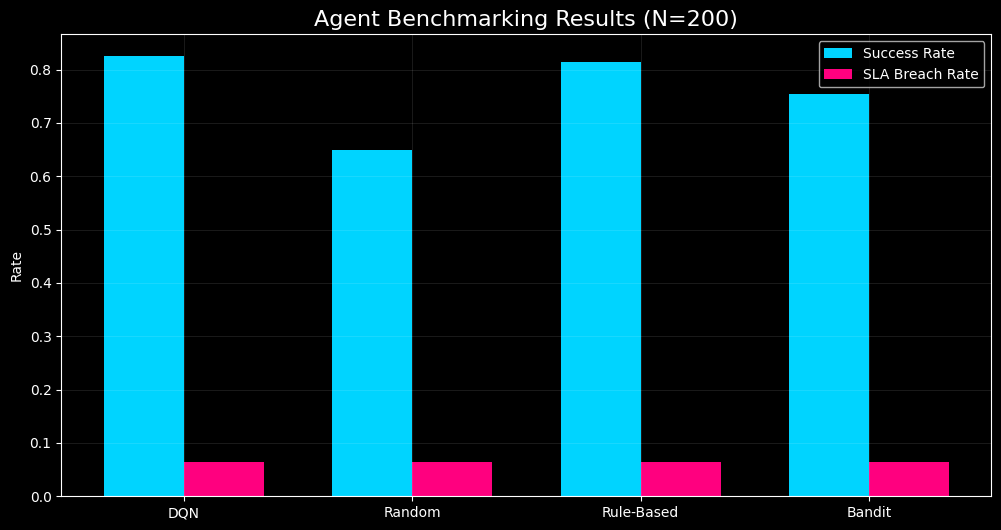

In [7]:
plt.figure(figsize=(12, 6))
x_labels = df_comp['agent']
x = np.arange(len(x_labels))
width = 0.35

plt.bar(x - width/2, df_comp['success_rate'], width, label='Success Rate', color=COLORS[0])
plt.bar(x + width/2, df_comp['sla_breach_rate'], width, label='SLA Breach Rate', color=COLORS[1])

plt.title("Agent Benchmarking Results (N=200)", fontsize=16)
plt.xticks(x, x_labels)
plt.ylabel("Rate")
plt.legend()
plt.grid(alpha=0.1)
plt.show()

## 3. RL VS Bandit Performance GAP

In [8]:
gap = df_comp.loc[df_comp['agent'] == 'DQN', 'avg_reward'].values[0] - df_comp.loc[df_comp['agent'] == 'Bandit', 'avg_reward'].values[0]
print(f"The DQN agent outperforms the Bandit agent by {gap:.2f} in average episodic reward.")
print("This indicates the value of hierarchical logic and long-term planning vs instantaneous reward maximization.")

The DQN agent outperforms the Bandit agent by 2.57 in average episodic reward.
This indicates the value of hierarchical logic and long-term planning vs instantaneous reward maximization.
